# Assignment 1 by Zheng Xia
* student ID: 15984230
---

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from scipy import fftpack
import pandas as pd

## Problem 1: Numerical integration of the SIR model


### 1.1(1) The parameter determining the epidemic

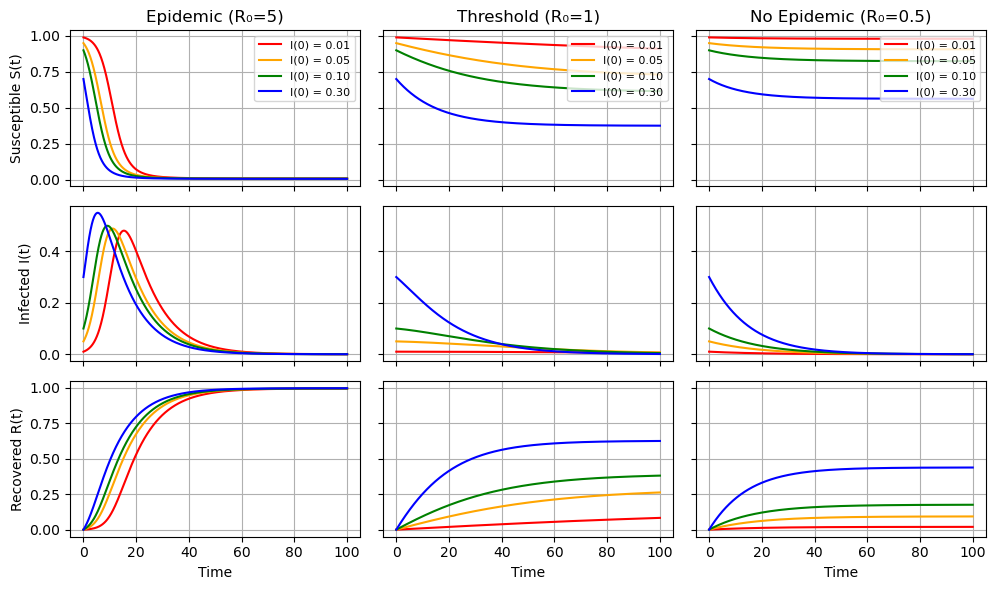

In [53]:
# Parameter
gamma = 0.1
beta_epidemic = 0.5    # R0 = 5 > 1 → epidemic
beta_no_epidemic = 0.05  # R0 = 0.5 < 1 → no epidemic
beta_threshold = 0.1 # R0 = 1 → threshold

# Time points
t = np.linspace(0, 100, 1000)

# Initial Condition(change to see different patters of the Phase-Space Plots)
initial_conditions = [
    (0.99, 0.01, 0.0),   # Small infection
    (0.95, 0.05, 0.0),   # Moderate infection
    (0.90, 0.10, 0.0),   # Larger infection
    (0.70, 0.30, 0.0),   # High infection
]

scenarios = {
    "Epidemic (R₀=5)": beta_epidemic,
    "Threshold (R₀=1)": beta_threshold,
    "No Epidemic (R₀=0.5)": beta_no_epidemic
}

# Define ODEs
def SIR_model(z,t,beta,gamma):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = - beta * z[0] * z[1]
    dIdt = beta * z[0] * z[1] - gamma * z[1]
    dRdt = gamma * z[1]
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt

# Plotting
fig, axs = plt.subplots(3, 3, figsize=(10, 6), sharex=True, sharey='row')

colors = ['red', 'orange', 'green', 'blue']

state_names = ['Susceptible S(t)', 'Infected I(t)', 'Recovered R(t)']
state_indices = [0, 1, 2]

for col, (scenario_name, beta) in enumerate(scenarios.items()):
    for row, (state_name, idx) in enumerate(zip(state_names, state_indices)):
        ax = axs[row, col]
        for color, (S0, I0, R0) in zip(colors, initial_conditions):
            z0 = [S0, I0, R0]
            sol = odeint(SIR_model, z0, t, args=(beta, gamma))
            ax.plot(t, sol[:, idx], label=f'I(0) = {I0:.2f}', color=color)
        
        if row == 0:
            ax.set_title(scenario_name)
        if row == 2:
            ax.set_xlabel('Time')
        if col == 0:
            ax.set_ylabel(state_name)
        
        ax.grid(True)
        if row == 0:
            ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig("img/SIR/sir_numerical.png", dpi=300, bbox_inches='tight')
plt.show()


### 1.1(2) Phase Space Plot

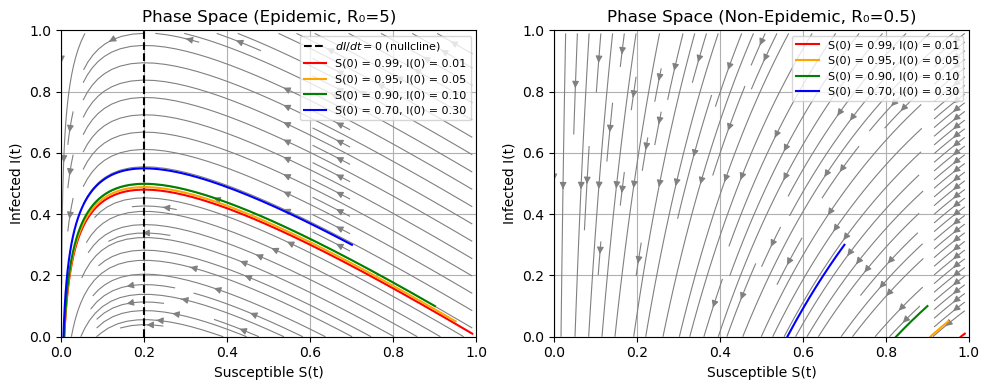

In [54]:
# Grid for S and I 
S, I = np.meshgrid(np.arange(0,1,0.01), np.arange(0,1,0.01))

# define the ODEs
def vector_field(beta, gamma):
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    return dS, dI

colors = ['red', 'orange', 'green', 'blue']

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Epidemic
dS_epi, dI_epi = vector_field(beta_epidemic, gamma)
axs[0].streamplot(S, I, dS_epi, dI_epi, density=1.2, color='gray', linewidth=0.8)
S_null_epi = gamma / beta_epidemic  # = 0.1 / 0.5 = 0.2
axs[0].axvline(x=S_null_epi, color='black', linestyle='--', linewidth=1.5, label=r'$dI/dt=0$ (nullcline)')
for z0, color in zip(initial_conditions, colors):
    sol = odeint(SIR_model, z0, t, args=(beta_epidemic, gamma))
    axs[0].plot(sol[:, 0], sol[:, 1], label=f'S(0) = {z0[0]:.2f}, I(0) = {z0[1]:.2f}', color=color)

axs[0].set_title('Phase Space (Epidemic, R₀=5)')
axs[0].set_xlabel('Susceptible S(t)')
axs[0].set_ylabel('Infected I(t)')
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)
axs[0].legend(loc='upper right', bbox_to_anchor=(1.0,1.0), fontsize=8)
axs[0].grid(True)

# Non-Epidemic
dS_nonepi, dI_nonepi = vector_field(beta_no_epidemic, gamma)
axs[1].streamplot(S, I, dS_nonepi, dI_nonepi, density=1.2, color='gray', linewidth=0.8)
for z0, color in zip(initial_conditions, colors):
    sol = odeint(SIR_model, z0, t, args=(beta_no_epidemic, gamma))
    axs[1].plot(sol[:, 0], sol[:, 1], label=f'S(0) = {z0[0]:.2f}, I(0) = {z0[1]:.2f}', color=color)

axs[1].set_title('Phase Space (Non-Epidemic, R₀=0.5)')
axs[1].set_xlabel('Susceptible S(t)')
axs[1].set_ylabel('Infected I(t)')
axs[1].set_xlim(0, 1)
axs[1].set_ylim(0, 1)
axs[1].legend(loc='upper right', bbox_to_anchor=(1.0,1.0), fontsize=8)
axs[1].grid(True)

plt.tight_layout()
plt.savefig("img/SIR/phase-space.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.2 Parameter Esitimation

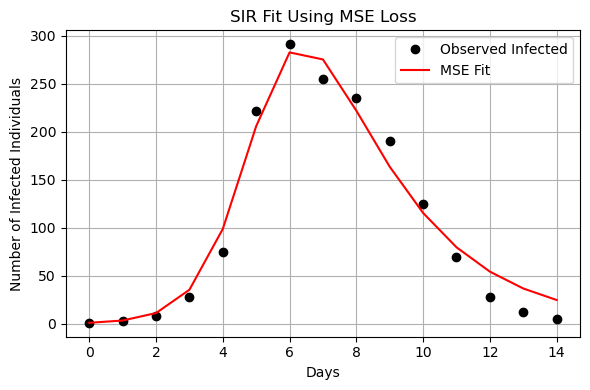


Fit Results:

  β (beta):  1.6651
  γ (gamma): 0.4476
  R₀:        3.7200
  MSE Loss:  272.7986


In [2]:
# Data import
days = np.arange(0,15)
N = 763
infected_data = np.array([1, 3, 8, 28, 75, 221, 291, 255, 235, 190, 125, 70, 28, 12, 5])

# Initial Conditions
I0 = infected_data[0]  #number of initial infected individuals
R0 = 0                 #number of initial recovered individuals
S0 = N - I0 - R0       #number of initial susceptible individuals
z0 = [S0, I0, R0]

# Define ODEs
def SIR_model(z,t,beta,gamma):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = - beta * z[0] * z[1]/N
    dIdt = beta * z[0] * z[1]/N - gamma * z[1]
    dRdt = gamma * z[1]
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt

# Defien Estimating Function (Try Different loss functions)
def mse_loss(params):
    beta, gamma = params
    sol  = odeint(SIR_model, z0, days, args=(beta, gamma))
    I_pred = sol[:,1]
    return np.mean((infected_data-I_pred)**2)

# Optimize parameters + Solve ODEs
result = minimize(mse_loss, [0.4, 0.1], bounds=[(0, 5), (0, 5)])
beta_fit, gamma_fit = result.x
R0_fit = beta_fit / gamma_fit
I_pred = odeint(SIR_model, z0, days, args=(beta_fit, gamma_fit))[:, 1]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r-', label='MSE Fit')
plt.title('SIR Fit Using MSE Loss')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("img/SIR/Model_fitting.png", dpi=300, bbox_inches='tight')
plt.show()

# Fit Results
print("\nFit Results:\n")
print(f"  β (beta):  {beta_fit:.4f}")
print(f"  γ (gamma): {gamma_fit:.4f}")
print(f"  R₀:        {R0_fit:.4f}")
print(f"  MSE Loss:  {result.fun:.4f}")

### 1.3 Vaccination

* Here I am going to compare 4 different kinds of vaccination strategies, including pre-epidemic vaccination as a prevention, random mass vaccination, targeted vaccination with and without risk grouping as reactive strategies.

* Paramter settings: 
(1) ${N}$ = 763: fixed total populiation.
(2) ${T}$ = 50 days : the duration of the simulation.
(3) The initial infection is 1 boy.
(4) According to the estimation in the question 1.2, the transimission rate ${β}$ is 1.67 and the recovery rate ${γ}$ is 0.45. The reproductive rate ${R_0}$ of the influenza is 3.72.
(5) It's also assumed the efficacy of the vaccine is 100%.

* Prior assumption:
* Strategy 1: Pre-epidemic Vaccination: 
(1)${p}$: proportion vaccinated before epidemic onset in pre-epidemic strategy.
(2)${V}_{Total}$ = ${p*N}$ : total number of people get vaccinated. 

* Strategy 2: Random Mass Vaccination(After onset)
(1)${μ_1}$ = $\frac{p}{T}$ : vaccination rate per person per unit time; matching the vaccination effort with Strategy 1.
(2)${\frac{dV}{dt}} = {μ_1*N}$ : average vaccition per unit time.

* Strategy 3: Targeted Vaccination without risk grouping(Susceptible only)
(1)${S(t) ≈ s*N ≈ 0.6*N}$: approximate and stable fraction of susceptible ${s = 0.6}$.
(2)${μ_2}$ = $\frac{p}{sT}$ : vaccination rate per person per unit time; matching the vaccination effort with Strategy 1.
(3)${\frac{dV}{dt}} = {μ_2*s*N}$ : average vaccition per unit time.

* Strategy 4: Targeted Vaccination with risk grouping 
(1)${f_H}$ = 30%; ${f_L}$ = 70% : the proportion of the high-risk and low-risk groups after the epidemic onset.
(2)${{S_H}(t) ≈ {f_H}*s*N}$; ${{S_L}(t) ≈ {f_L}*s*N}$
(3)${μ_3}{f_H} + {μ_4}{f_L} = \frac{p}{sT}$ : vaccination rate per person per unit time of high-risk and low-risk group, respectively; matching the vaccination effort with Strategy 1.
(4)${μ_3} = 2{μ_4}$, assuming ${μ_3} = 0.034$ and corresponding ${μ_4} = 0.017$. 
(5)${β={f_H}​⋅{β_H}​+{f_L}​⋅{β_L}} ​= 1.67$, assuming that ${{β_H} = 2.57}$ and the corresponding ${{β_L} = 1.29}$. 

* The following evaluation will be recoreded to compare the outcomes of these strategies: (1)total number of infectives; (2)peak time; (3)peak number of infectives (4)epidemic duration

---


Critical Vaccination Coverage (p_c): 0.4312
Total Number of Vaccinations (V_tot): 329

Vaccination Rate for Random Mass Vaccination (mu_1): 0.0088

Duration of Outbreak (Pre-epidemic Vaccination): 31 days
Peak Day (Pre-epidemic Vaccination): 12
Peak Infected (Pre-epidemic Vaccination): 76



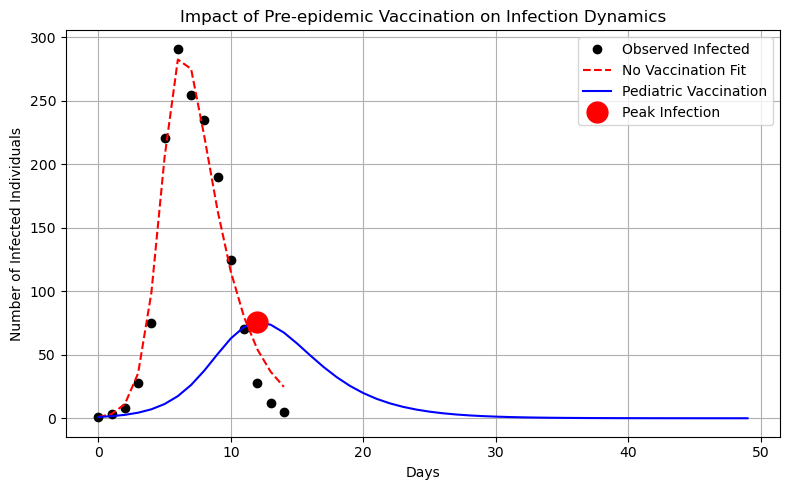

Duration of Outbreak (Random Mass Vaccination): 22 days
Peak Day (Random Mass Vaccination): 7
Peak Infected (Random Mass Vaccination): 254



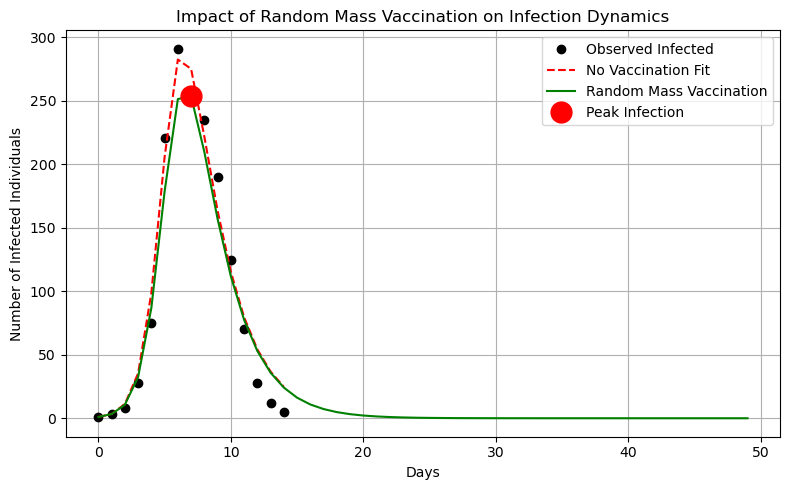

Duration of Outbreak (Targeted Vaccination without risk grouping): 23 days
Peak Day (Targeted Vaccination without risk grouping): 7
Peak Infected (Targeted Vaccination without risk grouping): 246



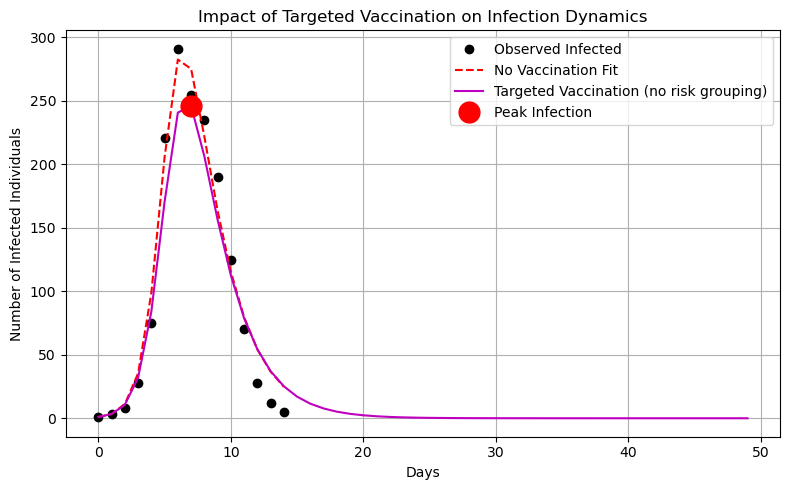

Duration of Outbreak (Targeted Vaccination with risk grouping): 23 days
Peak Day (Targeted Vaccination with risk grouping): 7
Peak Infected (Targeted Vaccination with risk grouping): 231



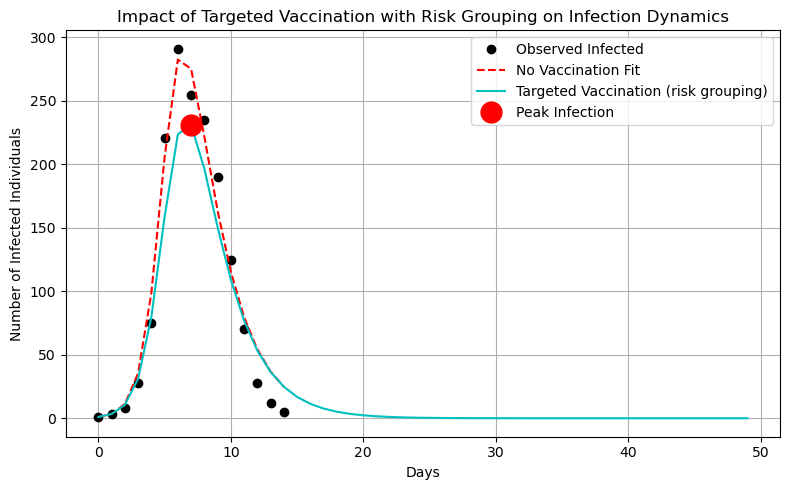

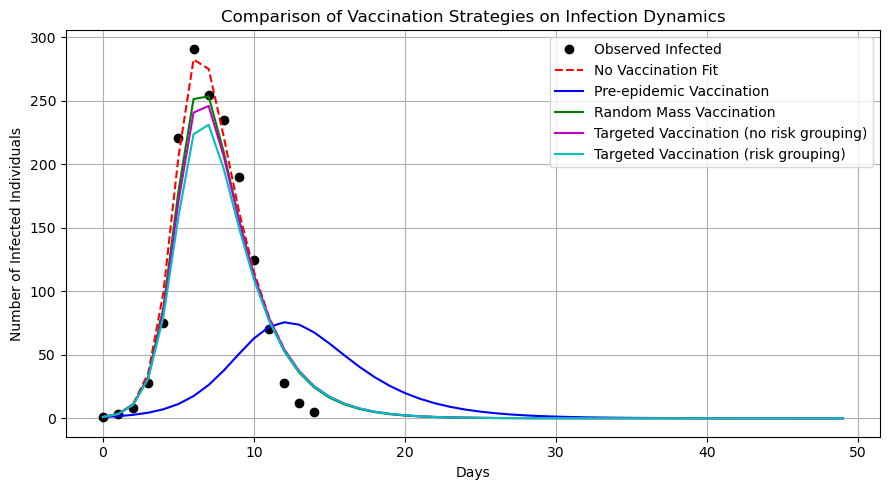

In [56]:
# Parameters 
T = np.arange(0,50)
p = 1-1/R0_fit - 0.3  # Lower Than Critical Vaccination Coverage
V_tot = p * N  # Total Number of Vaccinations
s = 0.6 # approximate fraction of susceptible individuals
f_H = 0.3 # fraction of high-risk individuals
f_L = 0.7 # fraction of low-risk individuals
mu_1 = p/T[-1] # Vaccination Rate for Random Mass Vaccination
mu_2 = p/(s*T[-1]) # Vaccination Rate for Targeted Vaccination 
mu_3 = 0.034 # Vaccination Rate for Targeted Vaccination (high-risk grouping)
mu_4 = 0.017 # Vaccination Rate for Targeted Vaccination (low-risk grouping)
beta_high = 2.57 # Transmission Rate for high-risk group
beta_low = 1.29 # Transmission Rate for low-risk grouping
print(f"\nCritical Vaccination Coverage (p_c): {p:.4f}")
print(f"Total Number of Vaccinations (V_tot): {V_tot:.0f}\n")
print(f"Vaccination Rate for Random Mass Vaccination (mu_1): {mu_1:.4f}\n")

# Pediatric Vaccination
# Initial Conditions
I0_ped = I0
S0_ped = (1-p) * N - I0
R0_ped = p * N
z0_ped = [S0_ped, I0_ped, R0_ped]
# Define ODEs 
def ped_vac(z, t, beta, gamma):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = - beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt
# Solve ODEs
sol_ped = odeint(ped_vac, z0_ped, T, args=(beta_fit, gamma_fit))
I_pred_ped = sol_ped[:, 1]
peak_day_ped = T[np.argmax(I_pred_ped)]
peak_infected_ped = np.max(I_pred_ped)
duration_ped = T[np.where(I_pred_ped < 1)[0][0]] if np.any(I_pred_ped < 1) else T[-1]
print(f"Duration of Outbreak (Pre-epidemic Vaccination): {duration_ped:.0f} days")
print(f"Peak Day (Pre-epidemic Vaccination): {peak_day_ped:.0f}")
print(f"Peak Infected (Pre-epidemic Vaccination): {peak_infected_ped:.0f}\n")
# Plot
plt.figure(figsize=(8,5))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r--', label='No Vaccination Fit')
plt.plot(T, I_pred_ped, 'b-', label='Pediatric Vaccination')
plt.plot(peak_day_ped, peak_infected_ped, 'ro', label='Peak Infection', markersize=15)
plt.title('Impact of Pre-epidemic Vaccination on Infection Dynamics')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Random Mass Vaccination
# Initial Conditions
I0_rmv = I0
R0_rmv = 0
S0_rmv = N - I0 - R0
V0_rmv = 0
z0_rmv = [S0_rmv, I0_rmv, R0_rmv, V0_rmv]
# Define ODEs
def random_mass_vac(z, t, beta, gamma, mu):
    S = z[0]
    I = z[1]
    R = z[2]
    V = z[3]
    dSdt = - beta * S * I / N - mu * S
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I - mu * R
    dVdt = mu * (S + I + R)
    dzdt = [dSdt, dIdt, dRdt, dVdt]
    return dzdt
# Solve ODEs
sol_rmv = odeint(random_mass_vac, z0_rmv, T, args=(beta_fit, gamma_fit, mu_1))
I_pred_rmv = sol_rmv[:, 1]
peak_day_rmv = T[np.argmax(I_pred_rmv)]
peak_infected_rmv = np.max(I_pred_rmv)
duration_rmv = T[np.where(I_pred_rmv < 1)[0][0]] if np.any(I_pred_rmv < 1) else T[-1]
print(f"Duration of Outbreak (Random Mass Vaccination): {duration_rmv:.0f} days")
print(f"Peak Day (Random Mass Vaccination): {peak_day_rmv:.0f}")
print(f"Peak Infected (Random Mass Vaccination): {peak_infected_rmv:.0f}\n")    
# Plot
plt.figure(figsize=(8,5))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r--', label='No Vaccination Fit')
plt.plot(T, I_pred_rmv, 'g-', label='Random Mass Vaccination')
plt.plot(peak_day_rmv, peak_infected_rmv, 'ro', label='Peak Infection', markersize=15)  
plt.title('Impact of Random Mass Vaccination on Infection Dynamics')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Targeted Vaccination without risk grouping(focus on susceptible)
# Initial Conditions
I0_tvac = I0
R0_tvac = 0
S0_tvac = N - I0 - R0
V0_tvac = 0
z0_tvac = [S0_tvac, I0_tvac, R0_tvac, V0_tvac]
# Define ODEs
def targeted_vac(z, t, beta, gamma, mu):
    S = z[0]
    I = z[1]
    R = z[2]
    V = z[3]
    dSdt = - beta * S * I / N - mu * S
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    dVdt = mu * S
    dzdt = [dSdt, dIdt, dRdt, dVdt]
    return dzdt
# Solve ODEs
sol_tvac = odeint(targeted_vac, z0_tvac, T, args=(beta_fit, gamma_fit, mu_2))
I_pred_tvac = sol_tvac[:, 1]
peak_day_tvac = T[np.argmax(I_pred_tvac)]
peak_infected_tvac = np.max(I_pred_tvac)
duration_tvac = T[np.where(I_pred_tvac < 1)[0][0]] if np.any(I_pred_tvac < 1) else T[-1]
print(f"Duration of Outbreak (Targeted Vaccination without risk grouping): {duration_tvac:.0f} days")
print(f"Peak Day (Targeted Vaccination without risk grouping): {peak_day_tvac:.0f}")
print(f"Peak Infected (Targeted Vaccination without risk grouping): {peak_infected_tvac:.0f}\n")    
# Plot
plt.figure(figsize=(8, 5))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r--', label='No Vaccination Fit')
plt.plot(T, I_pred_tvac, 'm-', label='Targeted Vaccination (no risk grouping)')
plt.plot(peak_day_tvac, peak_infected_tvac, 'ro', label='Peak Infection', markersize=15)
plt.title('Impact of Targeted Vaccination on Infection Dynamics')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() 

# Targeted Vaccination with risk grouping
# Initial Conditions
I0_tvac_rg = I0
R0_tvac_rg = 0
S0_tvac_rg = N - I0 - R0
V0_tvac_rg = 0
z0_tvac_rg = [S0_tvac_rg, I0_tvac_rg, R0_tvac_rg, V0_tvac_rg]
# Define ODEs
def targeted_vac_rg(z, t, beta_h, beta_l, gamma, mu_h, mu_l):
    S = z[0]
    I = z[1]
    R = z[2]
    V = z[3]
    S_h = f_H * S
    S_l = f_L * S
    I_h = f_H * I
    I_l = f_L * I
    dSdt = - beta_h * S_h * I / N - beta_l * S_l * I / N - mu_h * S_h - mu_l * S_l
    dIdt = beta_h * S_h * I / N + beta_l * S_l * I / N - gamma * I
    dRdt = gamma * I
    dVdt = mu_h * S_h + mu_l * S_l
    dzdt = [dSdt, dIdt, dRdt, dVdt]
    return dzdt
# Solve ODEs
sol_tvac_rg = odeint(targeted_vac_rg, z0_tvac_rg, T, args=(beta_high, beta_low, gamma_fit, mu_3, mu_4))
I_pred_tvac_rg = sol_tvac_rg[:, 1]
peak_day_tvac_rg = T[np.argmax(I_pred_tvac_rg)]
peak_infected_tvac_rg = np.max(I_pred_tvac_rg)
duration_tvac_rg = T[np.where(I_pred_tvac_rg < 1)[0][0]] if np.any(I_pred_tvac_rg < 1) else T[-1]
print(f"Duration of Outbreak (Targeted Vaccination with risk grouping): {duration_tvac_rg:.0f} days")
print(f"Peak Day (Targeted Vaccination with risk grouping): {peak_day_tvac_rg:.0f}")
print(f"Peak Infected (Targeted Vaccination with risk grouping): {peak_infected_tvac_rg:.0f}\n")    
# Plot
plt.figure(figsize=(8, 5))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r--', label='No Vaccination Fit')
plt.plot(T, I_pred_tvac_rg, 'c-', label='Targeted Vaccination (risk grouping)')
plt.plot(peak_day_tvac_rg, peak_infected_tvac_rg, 'ro', label='Peak Infection', markersize=15)
plt.title('Impact of Targeted Vaccination with Risk Grouping on Infection Dynamics')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Combination of the plots
plt.figure(figsize=(9, 5))
plt.plot(days, infected_data, 'ko', label='Observed Infected')
plt.plot(days, I_pred, 'r--', label='No Vaccination Fit')
plt.plot(T, I_pred_ped, 'b-', label='Pre-epidemic Vaccination')
plt.plot(T, I_pred_rmv, 'g-', label='Random Mass Vaccination')
plt.plot(T, I_pred_tvac, 'm-', label='Targeted Vaccination (no risk grouping)')
plt.plot(T, I_pred_tvac_rg, 'c-', label='Targeted Vaccination (risk grouping)')
plt.title('Comparison of Vaccination Strategies on Infection Dynamics')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("img/SIR/Vaccination.png", dpi=300, bbox_inches='tight')
plt.show()  


## Problem 2: Demography

### 2.1(1) Adding birth and natural death rates

Max population deviation (epidemic): 3.3566482926516983e-12


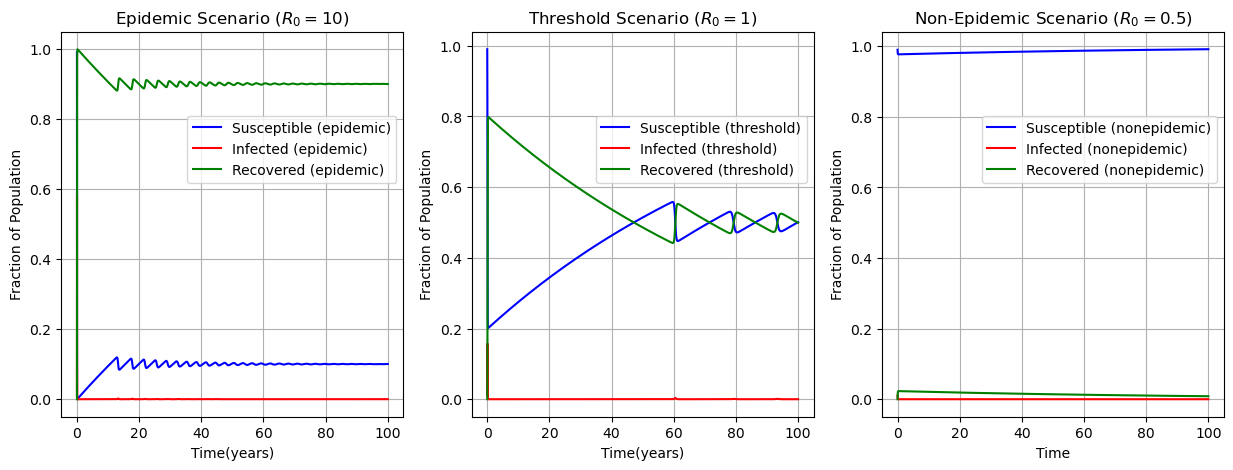

In [ ]:
# Define ODEs with birth and natural birth and death rates
def SIR_demo_model(z,t,beta,gamma,mu):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = mu * (S + I + R) - beta * S * I  - mu * S
    dIdt = beta * S * I  - gamma * I - mu * I
    dRdt = gamma * I - mu * R
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt
# Parameter
gamma = 52.14 # recovery rate (1/7 days) = 52.14 per year
beta_epidemic = 520   # per year
beta_no_epidemic = 30   # per year  
beta_threshold = 104.28 # per year (R0 = 1)
mu = 0.01 # birth and natural death rate 

# Time points 
t = np.linspace(0, 100, 5000) 
# Initial Condition 
# Small Infection 
S0 = 0.99 
I0 = 0.01 
R0 = 0.00 
z0 = [S0, I0, R0]

# Solve ODEs by odeint 
sol_epi = odeint(SIR_demo_model, z0, t, args=(beta_epidemic,gamma,mu)) 
sol_nonepi = odeint(SIR_demo_model, z0, t, args=(beta_no_epidemic,gamma,mu)) 
sol_threshold = odeint(SIR_demo_model, z0, t, args=(beta_threshold,gamma,mu))
total_epi = sol_epi[:, 0] + sol_epi[:, 1] + sol_epi[:, 2]
print("Max population deviation (epidemic):", np.max(np.abs(total_epi - 1)))
# Plot 
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5)) 
# Epidemic 
axs[0].plot(t, sol_epi[:, 0], label='Susceptible (epidemic)', color='blue') 
axs[0].plot(t, sol_epi[:, 1], label='Infected (epidemic)', color='red') 
axs[0].plot(t, sol_epi[:, 2], label='Recovered (epidemic)', color='green') 
axs[0].set_title(r'Epidemic Scenario ($R_0 = 10$)') 
axs[0].set_xlabel('Time(years)') 
axs[0].set_ylabel('Fraction of Population') 
axs[0].legend(loc='upper right', bbox_to_anchor=(1.0,0.8)) 
axs[0].grid(True) 

# Threshold
axs[1].plot(t, sol_threshold[:, 0], label='Susceptible (threshold)', color='blue') 
axs[1].plot(t, sol_threshold[:, 1], label='Infected (threshold)', color='red') 
axs[1].plot(t, sol_threshold[:, 2], label='Recovered (threshold)', color='green') 
axs[1].set_title(r'Threshold Scenario ($R_0 = 1$)') 
axs[1].set_xlabel('Time(years)') 
axs[1].set_ylabel('Fraction of Population') 
axs[1].legend(loc='upper right', bbox_to_anchor=(1.0,0.8)) 
axs[1].grid(True)   

# No Epidemic 
axs[2].plot(t, sol_nonepi[:, 0], label='Susceptible (nonepidemic)', color='blue') 
axs[2].plot(t, sol_nonepi[:, 1], label='Infected (nonepidemic)', color='red') 
axs[2].plot(t, sol_nonepi[:, 2], label='Recovered (nonepidemic)', color='green') 
axs[2].set_title(r'Non-Epidemic Scenario ($R_0 = 0.5$)') 
axs[2].set_xlabel('Time') 
axs[2].set_ylabel('Fraction of Population') 
axs[2].legend(loc='upper right', bbox_to_anchor=(1.0,0.8)) 
axs[2].grid(True) 

plt.savefig("img/Demo_SIR/sir_numerical.png", dpi=300, bbox_inches='tight')

### 2.1(2) The oscillation in I(t)

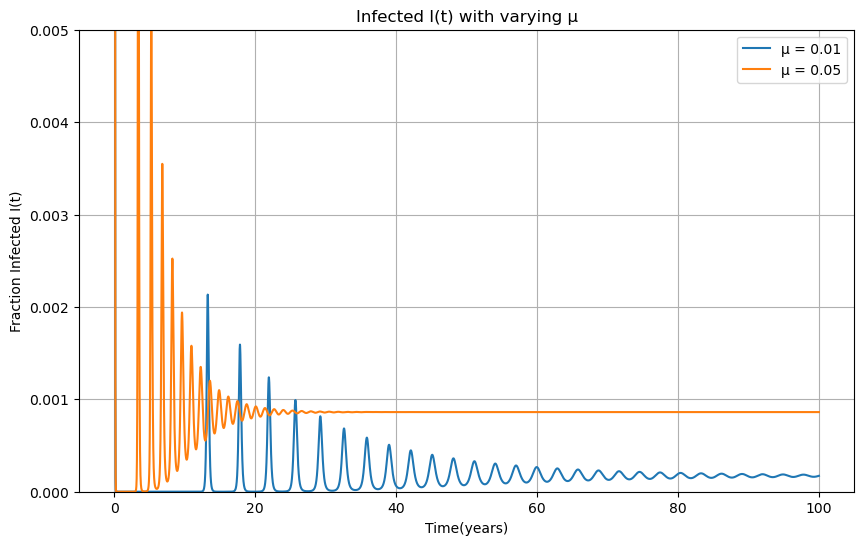

In [67]:
# Parameters
beta = 520   # epidemic case
gamma = 52.14
mu_values = [0.01, 0.05]   # test different mu
t = np.linspace(0, 100, 5000)

# Initial Condition 
# Small Infection 
S0 = 0.99 
I0 = 0.01 
R0 = 0.00 
z0 = [S0, I0, R0]

# Plot I(t) for varying mu
plt.figure(figsize=(10, 6))
for mu in mu_values:
    sol = odeint(SIR_demo_model, z0, t, args=(beta, gamma, mu))
    plt.plot(t, sol[:, 1], label=f'μ = {mu}')
plt.ylim(0,5e-3) 
plt.title("Infected I(t) with varying μ")
plt.xlabel("Time(years)")
plt.ylabel("Fraction Infected I(t)")
plt.legend()
plt.grid(True)
plt.savefig("img/Demo_SIR/Oscillation.png", dpi=300, bbox_inches='tight')
plt.show()


### 2.1(3) Phase Plot

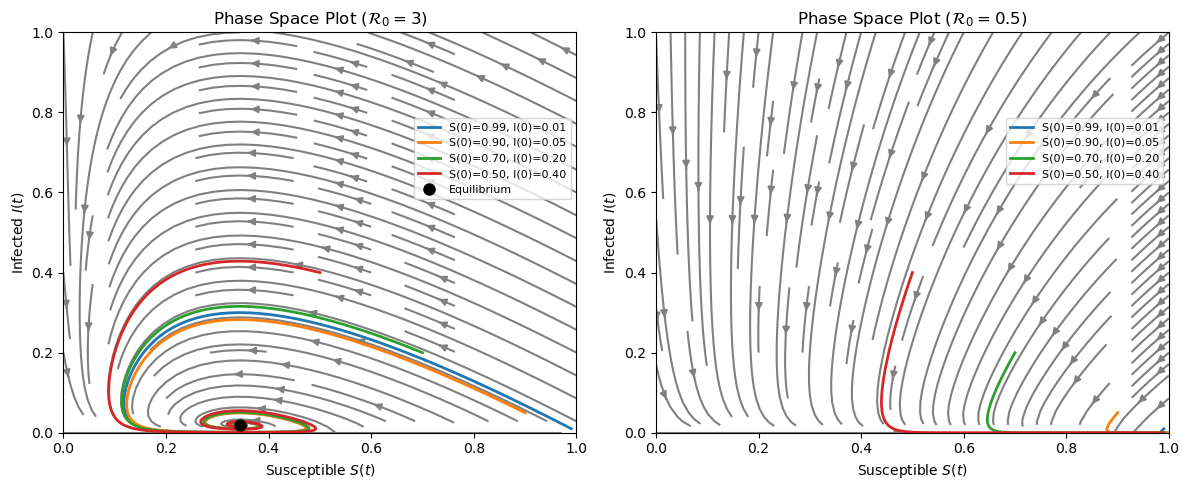

In [69]:
# Parameters
gamma = 1/3    # recovery rate (per day)
beta_epi = 1     # R0 = 3 (per day)
beta_nonepi = 1/6  # R0 = 0.5 (per day)
mu = 0.01           # birth/death rate (per day) Set a large mu to speed up the convergence

# Time points
t = np.linspace(0, 400, 10000)

# Demographic SIR model
def SIR_demo_model(z, t, beta, gamma, mu):
    S, I, R = z
    dSdt = mu * (1 - S) - beta * S * I
    dIdt = beta * S * I - (gamma + mu) * I
    dRdt = gamma * I - mu * R
    return [dSdt, dIdt, dRdt]

# Vector field for phase plot
def vector_field(S, I, beta, gamma, mu):
    dS = mu * (1 - S) - beta * S * I
    dI = beta * S * I - (gamma + mu) * I
    return dS, dI

# Parameters
gamma = 1 / 3
mu = 0.01
beta_epi = 1           # R₀ = 3
beta_nonepi = 1 / 6    # R₀ = 0.5
beta_values = [beta_epi, beta_nonepi]
titles = [r'$\mathcal{R}_0 = 3$', r'$\mathcal{R}_0 = 0.5$']

# Time vector
t = np.linspace(0, 400, 10000)

# Initial conditions
init_conditions = [
    [0.99, 0.01, 0.0],
    [0.90, 0.05, 0.05],
    [0.70, 0.20, 0.10],
    [0.50, 0.40, 0.10]
]

# Grid for vector field
S, I = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, beta in enumerate(beta_values):
    # Compute vector field
    dS, dI = vector_field(S, I, beta, gamma, mu)

    # Plot streamlines
    ax = axs[i]
    ax.streamplot(S, I, dS, dI, color='gray', density=1.2, arrowsize=1)

    # Plot solution trajectories
    for z0 in init_conditions:
        sol = odeint(SIR_demo_model, z0, t, args=(beta, gamma, mu))
        S_traj, I_traj = sol[:, 0], sol[:, 1]
        ax.plot(S_traj, I_traj, lw=2, label=f"S(0)={z0[0]:.2f}, I(0)={z0[1]:.2f}")

    # Compute and plot equilibrium
    R0 = beta / (gamma + mu)
    if R0 > 1:
        S_eq = 1 / R0
        I_eq = mu * (R0 - 1) / beta
        ax.plot(S_eq, I_eq, 'ko', markersize=8, label="Equilibrium")

    ax.set_title(f'Phase Space Plot ({titles[i]})')
    ax.set_xlabel("Susceptible $S(t)$")
    ax.set_ylabel("Infected $I(t)$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.0,0.8), fontsize=8) 

plt.tight_layout()
plt.savefig("img/Demo_SIR/Phase-space.png", dpi=300, bbox_inches='tight')
plt.show()



### 2.1(4) Quantifying the oscillations

Dominant Frequency: 0.0125, Period: 80.01 time units, Amplitude: 85.45


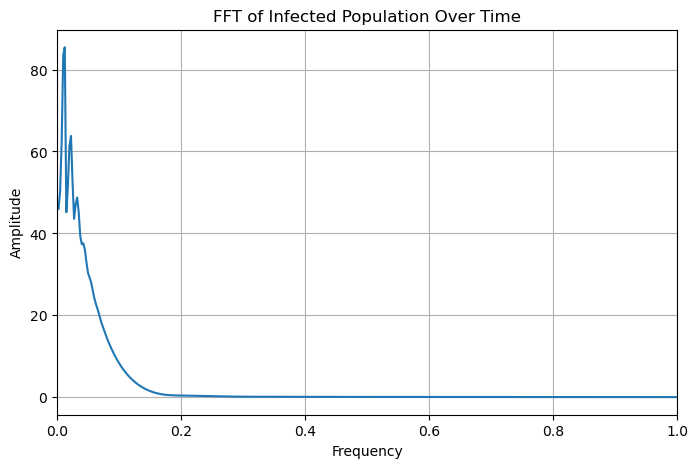

In [70]:
# Define ODEs with birth and natural birth and death rates
def SIR_demo_model(z,t,beta,gamma,mu):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = mu * (S + I + R) - beta * S * I  - mu * S
    dIdt = beta * S * I  - gamma * I - mu * I
    dRdt = gamma * I - mu * R
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt
# Parameters
gamma = 1/3    # recovery rate (per day)
beta_epi = 1     # R0 = 3 (per day)
mu = 0.01           # birth/death rate (per day) Set a large mu to speed up the convergence

# Time points 
t = np.linspace(0, 400, 10000) 

# Initial Condition 
# Small Infection 
S0 = 0.99 
I0 = 0.01 
R0 = 0.00 
z0 = [S0, I0, R0]

# Decompose I(t) using FFT
sol = odeint(SIR_demo_model, z0, t, args=(beta_epi, gamma, mu))
I_t = sol[:, 1]
I_t_centered = I_t - np.mean(I_t)
I_fft = fftpack.fft(I_t_centered)
dt = t[1] - t[0]
freq = fftpack.fftfreq(len(I_t), d=dt)
amp = np.abs(I_fft)

# Identify dominant frequency
pos_freq = freq[freq > 0]
pos_amp = amp[freq > 0]
dom_freq = pos_freq[np.argmax(pos_amp)]
period = 1 / dom_freq
print(f'Dominant Frequency: {dom_freq:.4f}, Period: {period:.2f} time units, Amplitude: {np.max(pos_amp):.2f}')

# Plot the FFT results
plt.figure(figsize=(8, 5))
plt.plot(pos_freq, pos_amp)
plt.xlim(0, 1)  # Focus on positive frequencies
plt.title('FFT of Infected Population Over Time')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig("img/Demo_SIR/Fourier_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()

### 2.2(1) Adding infection-induced mortality term

[0.1, 0.65]


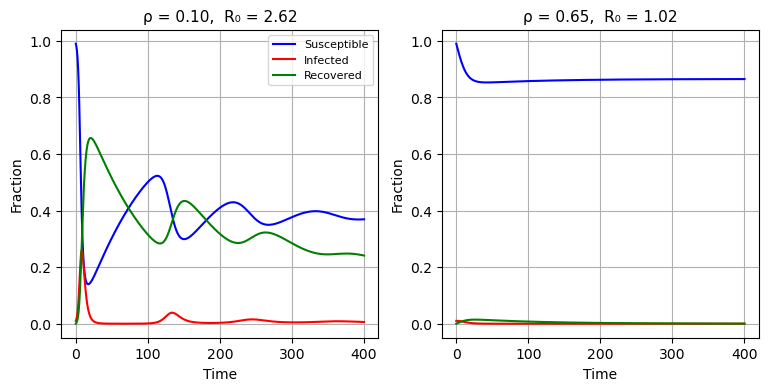

In [72]:
# Density-Dependent Transmission with Birth and Death Rates and Disease-Induced Mortality
def SIR_mortal_model(z,t,beta,gamma,mu,rho):
    S = z[0]
    I = z[1]
    R = z[2]
    dSdt = mu * (S + I + R) - beta * S * I  - mu * S
    dIdt = beta * S * I  - (gamma + mu)/(1 - rho) * I
    dRdt = (1-rho) * gamma * I - mu * R
    dzdt = [dSdt, dIdt, dRdt]
    return dzdt

# Parameter
gamma = 1/3    # recovery rate (per day)
beta = 1     # R0 = 3 (per day)    
mu = 0.01  # natural birth and death rate (per day)
rho_values = [0.1, 0.65]  # disease-induced mortality
print(rho_values)
# Time points
t = np.linspace(0, 400, 1000)
# Initial Condition
S0 = 0.99
I0 = 0.01
R0 = 0.00
z0 = [S0, I0, R0]

# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
axs = axs.flatten()

# Solve ODEs by odeint
for i, rho in enumerate(rho_values):
    sol = odeint(SIR_mortal_model, z0, t, args=(beta,gamma,mu,rho))
    S, I, R = sol[:, 0], sol[:, 1], sol[:, 2]
    R_0 = beta / ((gamma + mu)/(1 - rho))
    # Plot
    ax = axs[i]
    ax.plot(t, S, label='Susceptible', color='blue')
    ax.plot(t, I, label='Infected', color='red')
    ax.plot(t, R, label='Recovered', color='green')
    ax.set_title(f'ρ = {rho:.2f},  R₀ = {R_0:.2f}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction')
    ax.grid(True)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
plt.suptitle
plt.savefig("img/Demo_SIR/Mortal_solutions.png", dpi=300, bbox_inches='tight')
plt.show()



### 2.2.(2) Phase-space plot

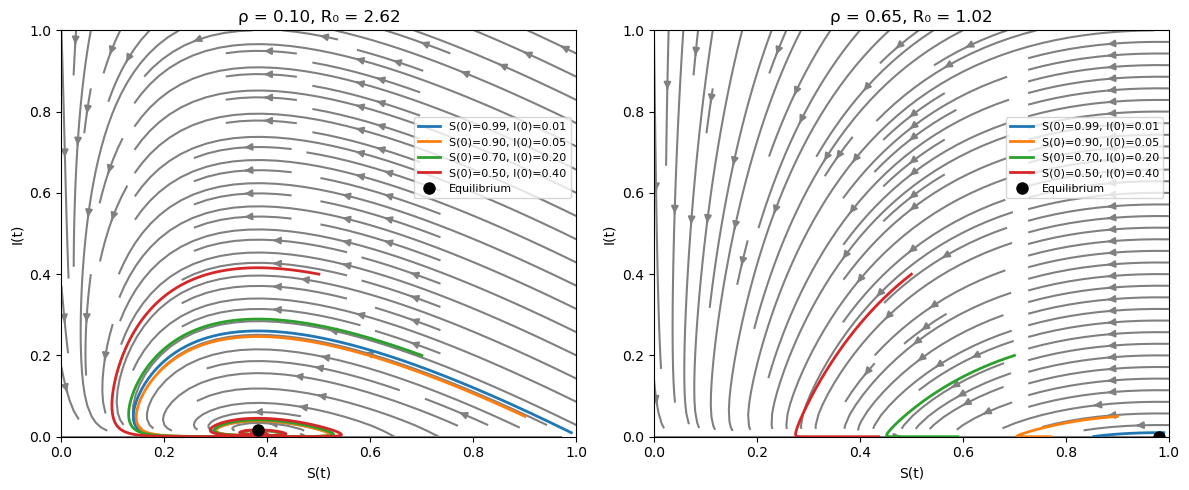

In [82]:
# Parameters
gamma = 1/3    # recovery rate (per day)
beta_epi = 1     # R0 = 3 (per day)
mu = 0.01           # birth/death rate (per day) Set a large mu to speed up the convergence
rho_values = [0.1, 0.65]  # disease-induced mortality

# Time points
t = np.linspace(0, 400, 10000)

# Initial conditions
init_conditions = [
    [0.99, 0.01, 0.0],
    [0.90, 0.05, 0.05],
    [0.70, 0.20, 0.10],
    [0.50, 0.40, 0.10]
]


# Grid for vector field
S, I = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, rho in enumerate(rho_values):
    # Vector field
    dS = mu * (S + I + (1-S-I)) - beta * S * I - mu * S
    dI = beta * S * I - (gamma + mu)/(1 - rho) * I
    
    # Plot vector field
    ax = axs[i]
    ax.streamplot(S, I, dS, dI, color="gray", density=1.2, arrowsize=1)

    # Plot trajectories for different initial conditions
    for z0 in init_conditions:
        sol = odeint(SIR_mortal_model, z0, t, args=(beta,gamma,mu,rho))
        S_traj, I_traj = sol[:,0], sol[:,1]
        ax.plot(S_traj, I_traj, lw=2, label=f"S(0)={z0[0]:.2f}, I(0)={z0[1]:.2f}")

    # Mark equilibrium point
    R0_eff = beta / ((gamma + mu)/(1 - rho))
    if R0_eff > 1:
        S_eq = 1 / R0_eff
        I_eq = mu * (R0_eff - 1) / beta
        ax.plot(S_eq, I_eq, 'ko', markersize=8, label="Equilibrium")

    ax.set_title(f'ρ = {rho:.2f}, R₀ = {R0_eff:.2f}')
    ax.set_xlabel("S(t)")
    ax.set_ylabel("I(t)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.0,0.8), fontsize=8) 

plt.tight_layout()
plt.savefig("img/Demo_SIR/Mortal_Phase-space.png", dpi=300, bbox_inches='tight')
plt.show()

### 2.2(3) Fourier decomposition

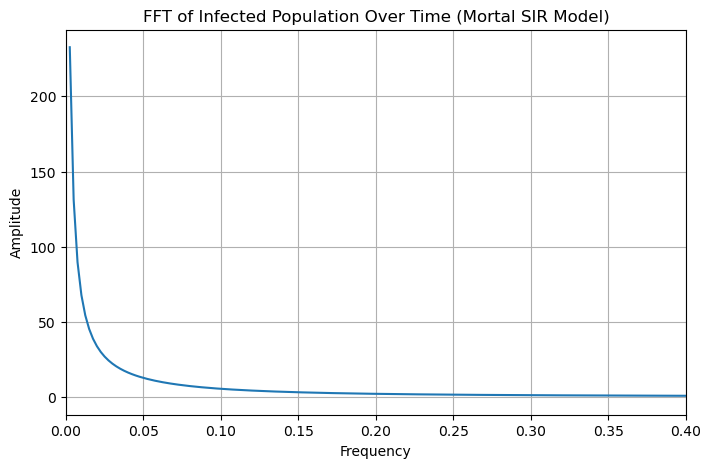

Dominant Frequency (Mortal SIR): 0.0025,Period: 400.04 time units, Amplitude: 232.60


In [83]:
# Fourier Transform for mortal SIR model
I_t_mor = sol[:, 2]
I_t_mor_centered = I_t_mor - np.mean(I_t_mor)
I_fft_mor = fftpack.fft(I_t_mor_centered)
dt = t[1] - t[0]   # time step
freq_mor = fftpack.fftfreq(len(I_t_mor), d=dt)
amp_mor = np.abs(I_fft_mor)

# Identify dominant frequency
pos_freq_mor = freq_mor[freq_mor > 0]
pos_amp_mor = amp_mor[freq_mor > 0]
dom_freq_mor = pos_freq_mor[np.argmax(pos_amp_mor)]
period_mor = 1 / dom_freq_mor

# Plot the FFT results
plt.figure(figsize=(8, 5))
plt.plot(pos_freq_mor, pos_amp_mor)
plt.xlim(0, 0.4)  # Focus on positive frequencies
plt.title('FFT of Infected Population Over Time (Mortal SIR Model)')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig("img/Demo_SIR/Mortal_Fourier.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Dominant Frequency (Mortal SIR): {dom_freq_mor:.4f},Period: {period_mor:.2f} time units, Amplitude: {np.max(pos_amp_mor):.2f}')

## Problem 3: Variants of the SIR model

### 3.1(1) SEIR Model

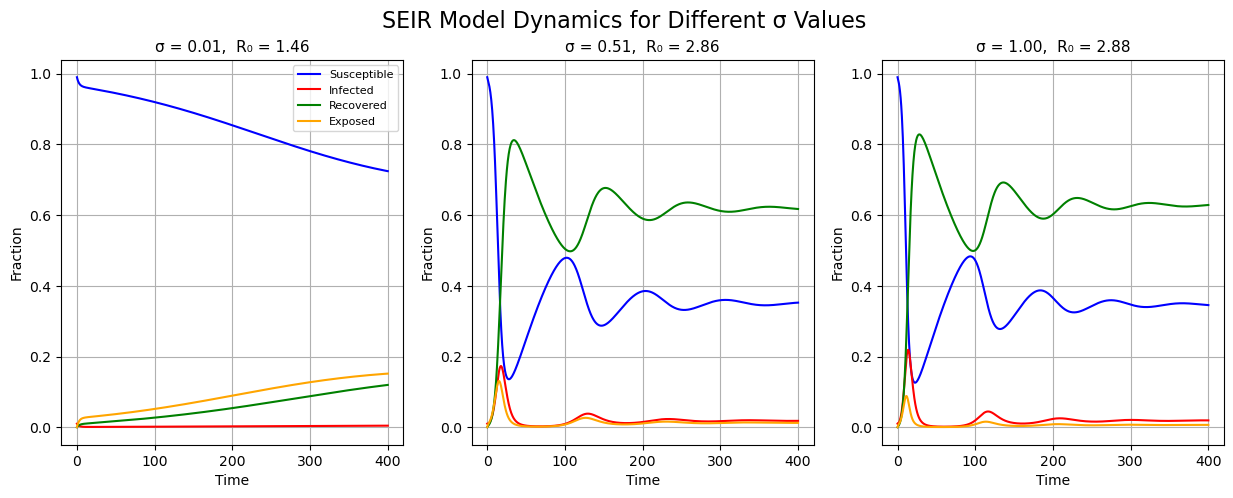

In [74]:
# define the ODEs for SEIR model
def SEIR_model(z, t, beta, gamma, mu,sigma):
    S = z[0]
    E = z[1]
    I = z[2]
    R = z[3]
    dSdt = mu * (S + E + I + R)- beta * S * I - mu * S
    dEdt = beta * S * I - (mu + sigma) * E
    dIdt = sigma * E - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    dzdt = [dSdt, dEdt, dIdt, dRdt]
    return dzdt

# Parameters
gamma = 1/3
beta = 1
mu = 0.01  
sigma_value = np.linspace(0.01,1,3)  # rate of progression from exposed to infectious
# Time points
t = np.linspace(0, 400, 1000)
# Initial Condition
S0 = 0.99
E0 = 0.00
I0 = 0.01
R0 = 0.00
z0 = [S0, E0, I0, R0]
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axs = axs.flatten()
# Solve ODEs by odeint
for i, sigma in enumerate(sigma_value):
    sol = odeint(SEIR_model, z0, t, args=(beta,gamma,mu,sigma))
    S, E, I, R = sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]
    R_0 = beta * (1 / (gamma + mu)) * (sigma / (sigma + mu))
# Plot
    ax = axs[i]
    ax.plot(t, S, label='Susceptible', color='blue')
    ax.plot(t, I, label='Infected', color='red')
    ax.plot(t, R, label='Recovered', color='green')
    ax.plot(t, E, label='Exposed', color='orange')
    ax.set_title(f'σ = {sigma:.2f},  R₀ = {R_0:.2f}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction')
    ax.grid(True)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
    
plt.suptitle('SEIR Model Dynamics for Different σ Values', fontsize=16)
plt.savefig("img/SEIR/Solutions.png", dpi=300, bbox_inches='tight')
plt.show()



### 3.1(2) Phase Plot

Equilibrium Point (Epidemic): S* = 0.3502, I* = 0.0186


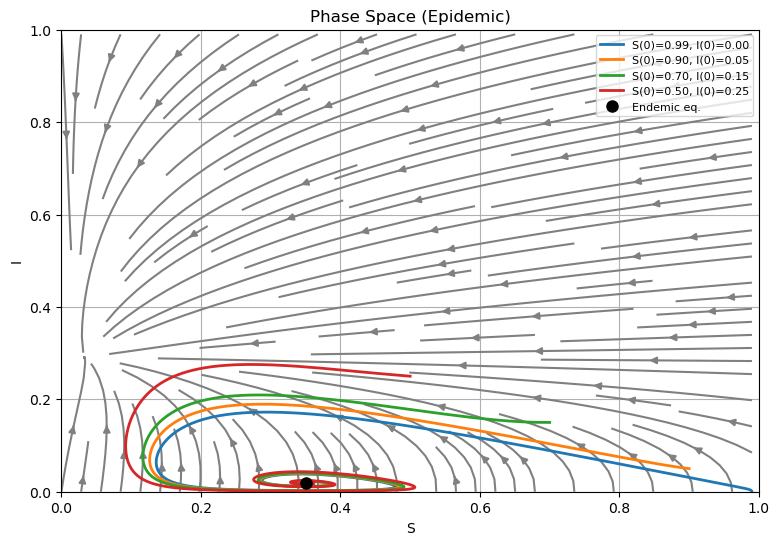

In [75]:
# SEIR model
def SEIR_model(z, t, beta, gamma, mu, sigma):
    S, E, I, R = z
    dS = mu * (S + E + I + R) - beta * S * I - mu * S
    dE = beta * S * I - (sigma + mu) * E
    dI = sigma * E - (mu + gamma) * I
    dR = gamma * I - mu * R
    return [dS, dE, dI, dR]

# Parameters
beta = 1
gamma = 1/3
mu = 0.01
sigma = 1/2     # incubation rate

# Time
t = np.linspace(0, 400, 2000)

# equilibrium point
R0_eff = beta * (1 / (gamma + mu)) * (sigma / (sigma + mu))
S_eq = 1 / R0_eff
I_eq = mu * (R0_eff - 1) / beta
print(f"Equilibrium Point (Epidemic): S* = {S_eq:.4f}, I* = {I_eq:.4f}")

# Grid for vector field (fixing E to a constant for 2D projection)
S, I = np.meshgrid(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01))
E_fixed = 0.2
def vector_field_SEIR(beta, gamma, mu, sigma):
    dS = mu * (S + E_fixed + I + (1 - S - E_fixed - I)) - beta * S * I - mu * S
    dI = sigma * E_fixed - (mu + gamma) * I
    return dS, dI
dS_seir, dI_seir = vector_field_SEIR(beta, gamma, mu, sigma)


plt.figure(figsize=(9, 6))

# Streamlines
plt.streamplot(S, I, dS_seir, dI_seir, density=1.2, color='gray')

# Different initial conditions (S0, E0, I0, R0)
init_conditions = [
    [0.99, 0.01, 0.0, 0.0],
    [0.90, 0.05, 0.05, 0.0],
    [0.70, 0.10, 0.15, 0.05],
    [0.50, 0.20, 0.25, 0.05]
]

# Solve ODEs for each trajectory
for z0 in init_conditions:
    sol_seir = odeint(SEIR_model, z0, t, args=(beta,gamma,mu,sigma))
    plt.plot(sol_seir[:, 0], sol_seir[:, 2], lw=2, label=f"S(0)={z0[0]:.2f}, I(0)={z0[2]:.2f}")

plt.plot(S_eq, I_eq, 'ko', markersize=8, label="Endemic eq.")
plt.title('Phase Space (Epidemic)')
plt.xlabel('S')
plt.ylabel('I')
plt.legend(loc='upper right', fontsize=8)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.savefig("img/SEIR/Phase-space.png", dpi=300, bbox_inches='tight')
plt.show()


### 3.1(3) Fourier Decoposition

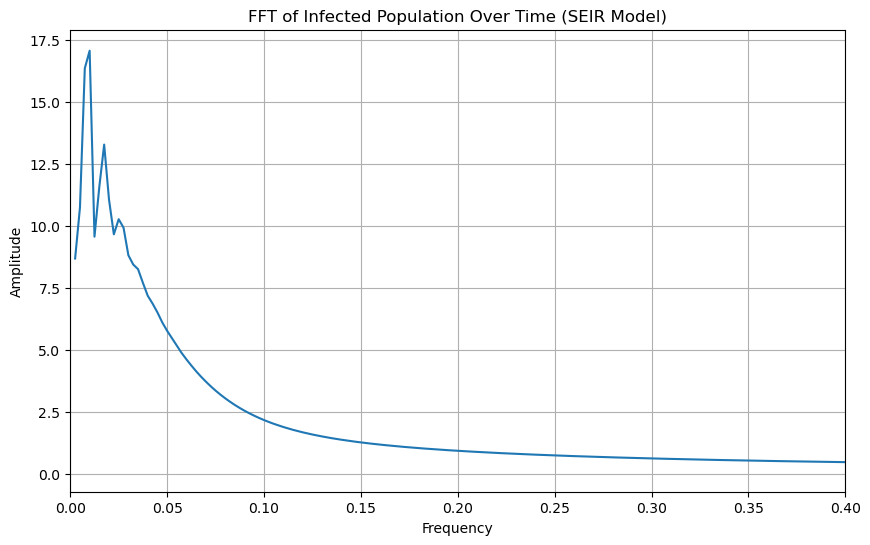

Dominant Frequency (SEIR): 0.0100,Period: 100.05 time units, Amplitude: 17.08


In [76]:
# Fourier Transform for SEIR model
I_t_seir = sol_seir[:, 2]
I_t_seir_centered = I_t_seir - np.mean(I_t_seir)
I_fft_seir = fftpack.fft(I_t_seir_centered)
dt = t[1] - t[0]   # time step
freq_seir = fftpack.fftfreq(len(I_t_seir), d=dt)
amp_seir = np.abs(I_fft_seir)

# Identify dominant frequency
pos_freq_seir = freq_seir[freq_seir > 0]
pos_amp_seir = amp_seir[freq_seir > 0]
dom_freq_seir = pos_freq_seir[np.argmax(pos_amp_seir)]
period_seir = 1 / dom_freq_seir

# Plot the FFT results
plt.figure(figsize=(10, 6))
plt.plot(pos_freq_seir, pos_amp_seir)
plt.xlim(0, 0.4)  # Focus on positive frequencies
plt.title('FFT of Infected Population Over Time (SEIR Model)')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig("img/SEIR/Fourier.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Dominant Frequency (SEIR): {dom_freq_seir:.4f},Period: {period_seir:.2f} time units, Amplitude: {np.max(pos_amp_seir):.2f}')

### 3.2(1) Seasonal effects

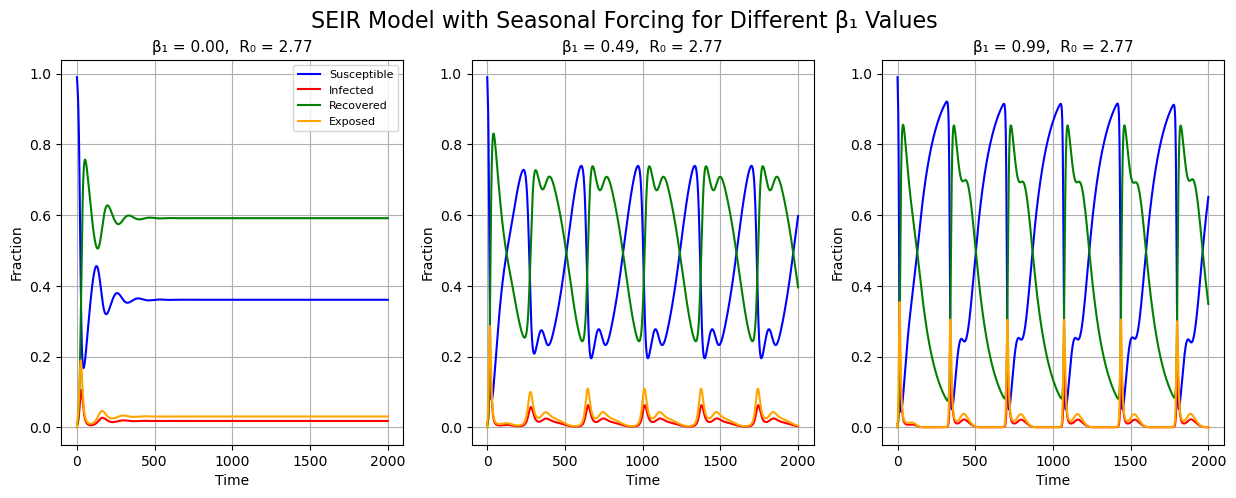

In [77]:
# Addition of seasonal forcing to the SEIR model
def SEIR_seasonal_model(z, t, beta0, beta1, gamma, mu, sigma, omega):
    S = z[0]
    E = z[1]
    I = z[2]
    R = z[3]
    beta_t = beta0 * (1 + beta1 * np.cos(omega * t))  # Seasonal transmission rate
    dSdt = mu * (S + E + I + R) - beta_t * S * I - mu * S
    dEdt = beta_t * S * I - (mu + sigma) * E
    dIdt = sigma * E - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    dzdt = [dSdt, dEdt, dIdt, dRdt]
    return dzdt

# Parameters
gamma = 1/3
beta0 = 1
beta1_value = np.linspace(0,0.99,3)  # Amplitude of seasonal variation
mu = 0.01  # natural birth and death rate (per capita per unit time
sigma = 0.2  # rate of progression from exposed to infectious
omega = 2 * np.pi / 365  # Seasonal frequency (annual cycle)

# Time points
t = np.linspace(0, 2000, 10000)

# Initial Condition
S0 = 0.99
E0 = 0.00
I0 = 0.01
R0 = 0.00
z0 = [S0, E0, I0, R0]

# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axs = axs.flatten()

# Solve ODEs by odeint
for i, beta1 in enumerate(beta1_value):
    sol = odeint(SEIR_seasonal_model, z0, t, args=(beta0,beta1,gamma,mu,sigma,omega))
    S, E, I, R = sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]
    R_0 = beta0 * (1 / (gamma + mu)) * (sigma / (sigma + mu))
    # Plot
    ax = axs[i]
    ax.plot(t, S, label='Susceptible', color='blue')
    ax.plot(t, I, label='Infected', color='red')
    ax.plot(t, R, label='Recovered', color='green')
    ax.plot(t, E, label='Exposed', color='orange')
    ax.set_title(f'β₁ = {beta1:.2f},  R₀ = {R_0:.2f}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction')
    ax.grid(True)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
plt.suptitle('SEIR Model with Seasonal Forcing for Different β₁ Values', fontsize=16)
plt.savefig("img/SEIR/Seasonal_solutions.png", dpi=300, bbox_inches='tight')
plt.show()


### 3.2(2) Phase plot

Equilibrium Point (Epidemic): S* = 0.3605, I* = 0.0177


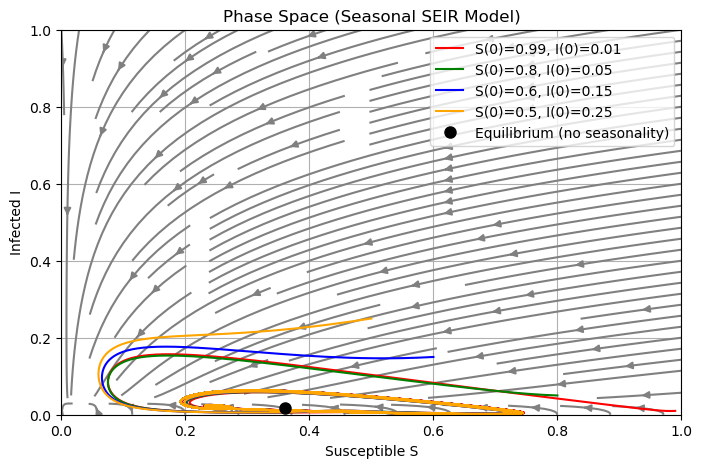

In [78]:
#Seasonal SEIR model
def SEIR_seasonal_model(z, t, beta0, beta1, gamma, mu, sigma, omega):
    S = z[0]
    E = z[1]
    I = z[2]
    R = z[3]
    beta_t = beta0 * (1 + beta1 * np.cos(omega * t))  # Seasonal transmission rate
    dSdt = mu * (S + E + I + R) - beta_t * S * I - mu * S
    dEdt = beta_t * S * I - (mu + sigma) * E
    dIdt = sigma * E - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    dzdt = [dSdt, dEdt, dIdt, dRdt]
    return dzdt

# Parameters
gamma = 1/3
beta0 = 1
beta1 = 0.5  # Amplitude of seasonal variation
mu = 0.01  # natural birth and death rate (per capita per unit time
sigma = 0.2  # rate of progression from exposed to infectious
omega = 2 * np.pi / 365  # Seasonal frequency (annual cycle)

# Time points
t = np.linspace(0, 2000, 10000)

# equilibrium point
R0_eff = beta0 * (1 / (gamma + mu)) * (sigma / (sigma + mu))
S_eq = 1 / R0_eff
I_eq = mu * (R0_eff - 1) / beta0
print(f"Equilibrium Point (Epidemic): S* = {S_eq:.4f}, I* = {I_eq:.4f}")

# Grid for vector field (fixing E to a constant for 2D projection)
S, I = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
E_fixed, R_fixed = 0.05, 0.0
U, V = [], []
for Si, Ii in zip(S.flatten(), I.flatten()):
    dS, dE, dI, dR = SEIR_seasonal_model([Si, E_fixed, Ii, R_fixed], 0, beta0, beta1, gamma, mu, sigma, omega)
    U.append(dS)
    V.append(dI)
U, V = np.array(U).reshape(S.shape), np.array(V).reshape(I.shape)

# Plot vector field
plt.figure(figsize=(8,5))
plt.streamplot(S, I, U, V, color='gray', density=1.2, arrowsize=1)

# Different initial conditions
IC_list = [
    [0.99, 0.01, 0.01, 0.0],   # mostly susceptible, small infection
    [0.80, 0.10, 0.05, 0.05],  # medium S, some exposed
    [0.60, 0.20, 0.15, 0.05],  # higher infection
    [0.50, 0.20, 0.25, 0.05]   # strong infection start
]
colors = ['red', 'green', 'blue', 'orange']

for z0, color in zip(IC_list, colors):
    sol = odeint(SEIR_seasonal_model, z0, t, args=(beta0, beta1, gamma, mu, sigma, omega))
    plt.plot(sol[:, 0], sol[:, 2], color=color, label=f"S(0)={z0[0]}, I(0)={z0[2]}")

plt.plot(S_eq, I_eq, 'ko', markersize=8, label="Equilibrium (no seasonality)")
plt.title('Phase Space (Seasonal SEIR Model)')
plt.xlabel('Susceptible S')
plt.ylabel('Infected I')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper right', bbox_to_anchor=(1.0,1.0), fontsize=10)
plt.grid(True)
plt.savefig("img/SEIR/Seasonal_Phase-space.png", dpi=300, bbox_inches='tight')
plt.show()

### 3.2(3) Fourier Decomposition

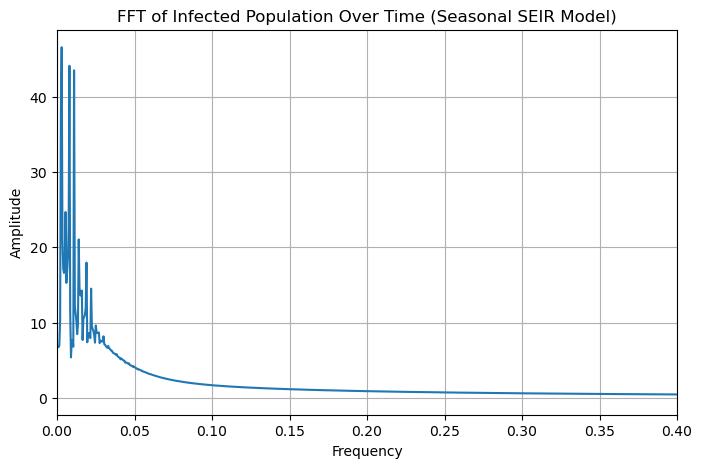

Dominant Frequency (Seasonal SEIR): 0.0100,Period: 100.05 time units, Amplitude: 17.08


In [79]:
# Fourier Transform for seasonal SEIR model
I_t_sea = sol[:, 2]
I_t_sea_centered = I_t_sea - np.mean(I_t_sea)
I_fft_sea = fftpack.fft(I_t_sea_centered)
dt = t[1] - t[0]   # time step
freq_sea = fftpack.fftfreq(len(I_t_sea), d=dt)
amp_sea = np.abs(I_fft_sea)

# Identify dominant frequency
pos_freq_sea = freq_sea[freq_sea > 0]
pos_amp_sea = amp_sea[freq_sea > 0]
dom_freq_sea = pos_freq_sea[np.argmax(pos_amp_sea)]
period_sea = 1 / dom_freq_sea

# Plot the FFT results
plt.figure(figsize=(8, 5))
plt.plot(pos_freq_sea, pos_amp_sea)
plt.xlim(0, 0.4)  # Focus on positive frequencies
plt.title('FFT of Infected Population Over Time (Seasonal SEIR Model)')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.savefig("img/SEIR/Seasonal_Fourier.png", dpi=300, bbox_inches='tight')
plt.show()

print(f'Dominant Frequency (Seasonal SEIR): {dom_freq_seir:.4f},Period: {period_seir:.2f} time units, Amplitude: {np.max(pos_amp_seir):.2f}')